### **파일 컬럼 역할부터 구분하자**

- 열연압연_운전데이터.csv
- 열연압연_정비이력.csv

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
df = pd.read_csv("..\\Data\\열연압연_운전데이터.csv", encoding='utf-8')
hist = pd.read_csv("..\\Data\\열연압연_정비이력.csv", encoding='utf-8')

In [3]:
df.info()

df.head(10)


print("\n=== 컬럼별 고유명 출력 ===\n")
for c in df.columns:
    # 텍스트(Object) 타입 컬럼만 골라내거나, 모든 컬럼을 보되 컬럼명을 명시합니다.
    print(f"[{c}] 컬럼의 고유값 ({df[c].nunique()}개):")
    print(df[c].unique())
    print("-" * 50)  # 구분선 추가

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   day                       80 non-null     int64  
 1   date                      80 non-null     str    
 2   steel_grade               80 non-null     str    
 3   target_thickness_mm       80 non-null     float64
 4   entry_temp_c              80 non-null     float64
 5   line_speed_mpm            80 non-null     float64
 6   rolling_force_ton         80 non-null     float64
 7   roll_gap_corr_mm          80 non-null     float64
 8   thickness_dev_mm          80 non-null     float64
 9   workroll_vib_mm_s         80 non-null     float64
 10  motor_current_a           80 non-null     float64
 11  hyd_pressure_bar          80 non-null     float64
 12  hyd_oiltemp_c             80 non-null     float64
 13  hyd_level_pct             80 non-null     float64
 14  days_to_next_roll_chang

In [4]:
hist.info()

hist.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   record_id    5 non-null      str  
 1   event_date   5 non-null      str  
 2   day          5 non-null      int64
 3   equipment    5 non-null      str  
 4   work_type    5 non-null      str  
 5   description  5 non-null      str  
 6   result       5 non-null      str  
dtypes: int64(1), str(6)
memory usage: 412.0 bytes


,record_id,event_date,day,equipment,work_type,description,result
0,M01,2026-06-14,14,작업롤,점검,표면 및 진동 점검,이상 없음
1,M02,2026-07-01,31,유압 유닛,예방정비,필터 정기 교체,정상
2,M03,2026-07-19,49,유압 압력 센서,점검,압력값 단발성 급등 확인 후 단자 재체결,센서 접촉 불량 확인
3,M04,2026-08-06,67,작업롤,고장수리,두께 편차 증가 및 롤 표면 마모 확인 후 교체,교체 후 두께 편차 정상화
4,M05,2026-08-13,74,작업롤,예방정비,정기 윤활 및 표면 점검,이상 없음


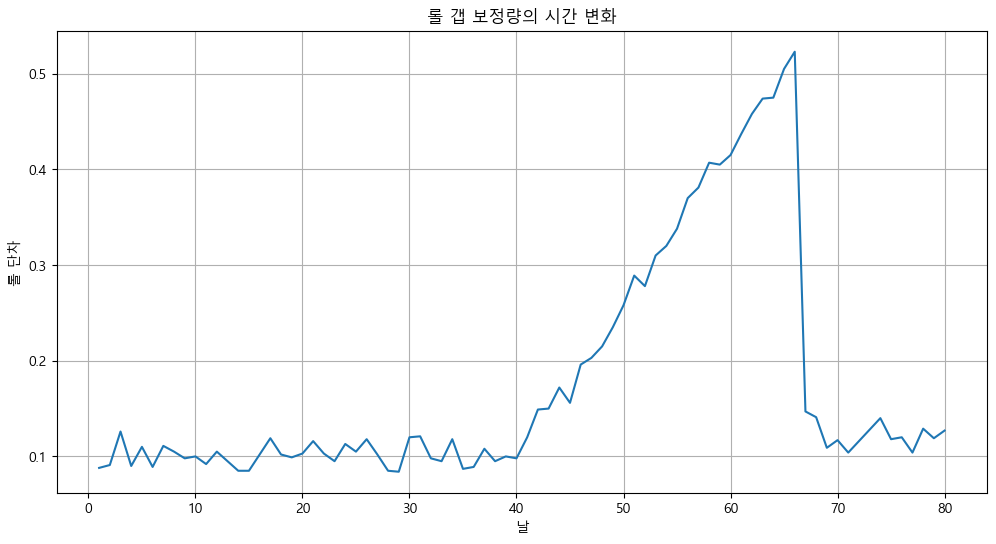

In [5]:
plt.figure(figsize=(12,6))
plt.plot(df["day"], df["roll_gap_corr_mm"])
plt.title("롤 갭 보정량의 시간 변화")
plt.xlabel("날")
plt.ylabel("롤 단차")
plt.grid()
plt.show()

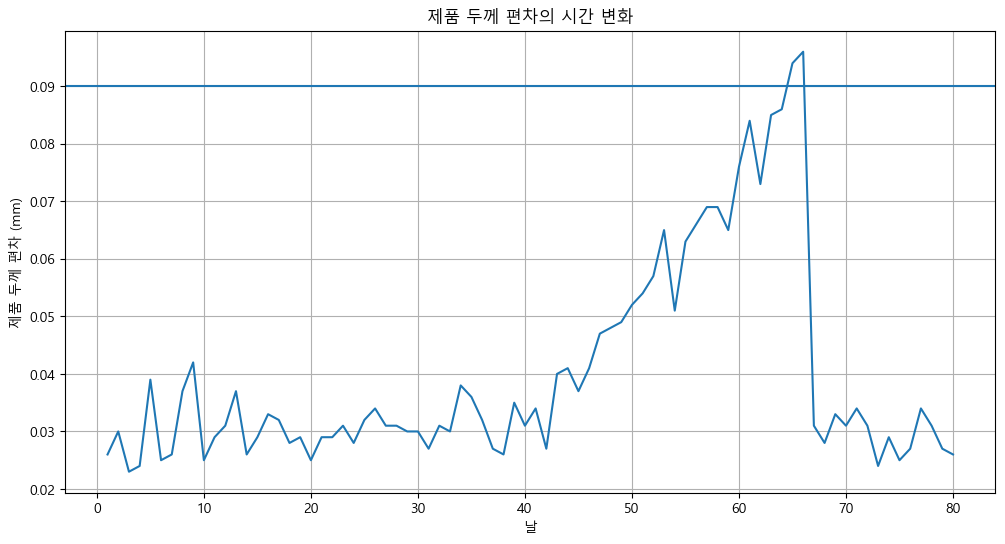

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df["day"], df["thickness_dev_mm"])
plt.title("제품 두께 편차의 시간 변화")
plt.xlabel("날")
plt.ylabel("제품 두께 편차 (mm)")
plt.axhline(y=0.09)
plt.grid()
plt.show()

### **그래프 분석 기록**

1. 어느 날부터 이전과 다른 지속적인 변화가 보이나요?
> 40일자부터 지속적인 변화가 보였다

2. 스파이크인가요, 누적되는 추세인가요?
> 가파르게 누적되는 추세처럼 보인다

3. 두 그래프의 변화 시점은 비슷한가요?
> 65일 즈음으로 비슷하다

### **2. 네 가지 원인 후보를 관련 신호와 이력으로 하나씩 검토하세요**


roll_gap_corr_mm 평균:  0.1750375
roll_gap_corr_mm 중앙값:  0.118
roll_gap_corr_mm 표준편차:  0.12191919338311696
thickness_dev_mm 평균:  0.039925
thickness_dev_mm 중앙값:  0.0315
thickness_dev_mm 표준편차:  0.018142038041625796
workroll_vib_mm_s 평균:  2.376375
workroll_vib_mm_s 중앙값:  2.37
workroll_vib_mm_s 표준편차:  0.16705372250426404


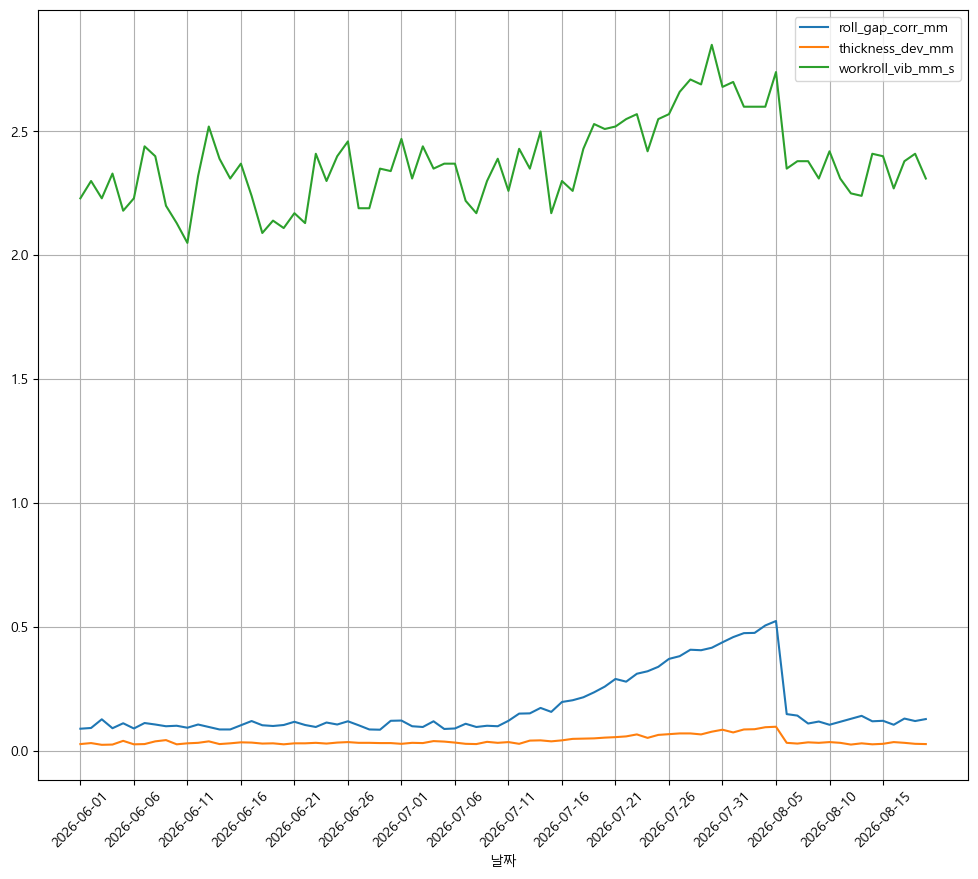

In [7]:
# 01. 작업롤 마모
# roll_gap_corr, thickness_dev, workroll_vib
col_roll = ["roll_gap_corr_mm", "thickness_dev_mm", "workroll_vib_mm_s"]
for c in col_roll:
    print(c,"평균: ", df[c].mean())
    print(c, "중앙값: ", df[c].median())
    print(c, "표준편차: ", df[c].std())

ax = df.plot(x="date", y=col_roll, figsize=(12,10))
interval = 5
ax.set_xticks(range(0, len(df), interval))
ax.set_xticklabels(df["date"].iloc[::interval])
plt.xlabel("날짜")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

---
> 65일 즈음 3개 컬럼 데이터 값이 동시에 떨어지는 양상을 보임
---

hyd_pressure_bar 평균:  152.27624999999998
hyd_pressure_bar 중앙값:  151.85000000000002
hyd_pressure_bar 표준편차:  3.1498138884139766
hyd_oiltemp_c 평균:  44.095000000000006
hyd_oiltemp_c 중앙값:  44.1
hyd_oiltemp_c 표준편차:  0.4547638140642663
hyd_level_pct 평균:  88.53875000000001
hyd_level_pct 중앙값:  88.6
hyd_level_pct 표준편차:  0.34328780780467816


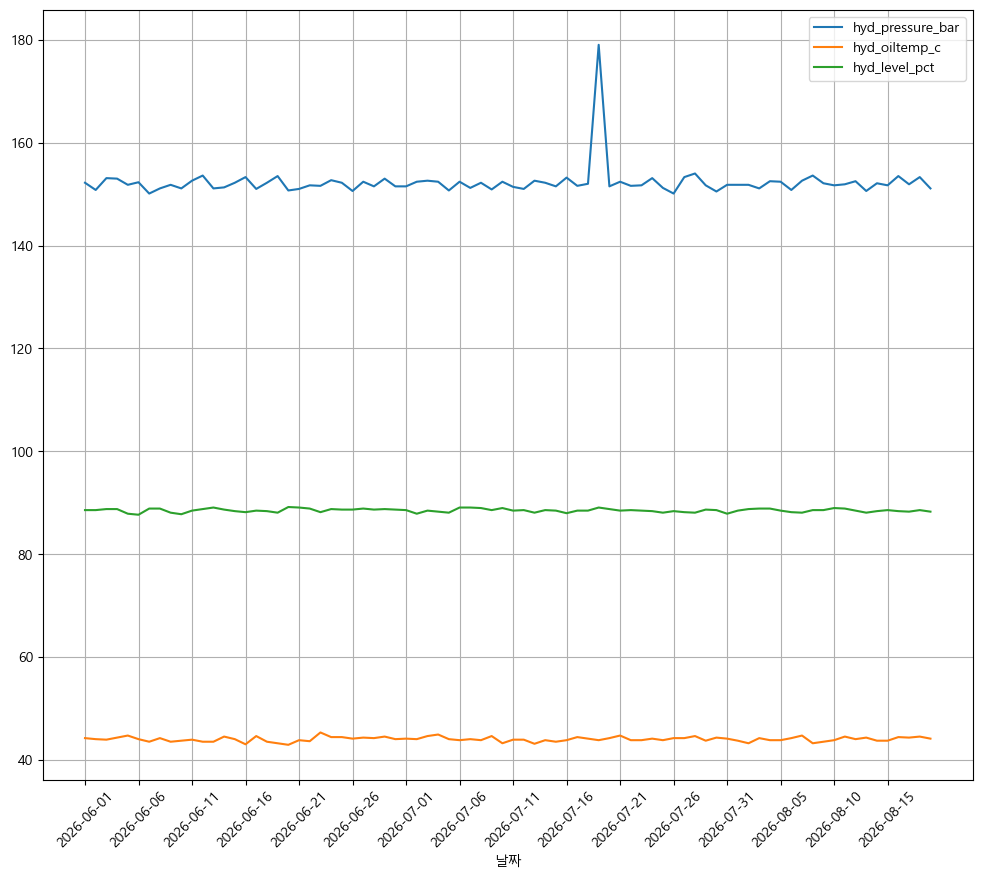

In [8]:
# 02. 유압계통 이상
col_hyd = ["hyd_pressure_bar", "hyd_oiltemp_c", "hyd_level_pct"]

for c in col_hyd:
    print(c, "평균: ", df[c].mean())
    print(c, "중앙값: ", df[c].median())
    print(c, "표준편차: ", df[c].std())

ax = df.plot(x="date", y=col_hyd, figsize=(12, 10))
interval = 5
ax.set_xticks(range(0, len(df), interval))
ax.set_xticklabels(df["date"].iloc[::interval])
plt.xlabel("날짜")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

---
> 47일 즈음 hyd_pressure_bar 값이 스파이크가 튀었음
---


=== steel grade unique 값 ===

<StringArray>
['SS400', 'SPHC', 'SAPH440']
Length: 3, dtype: str


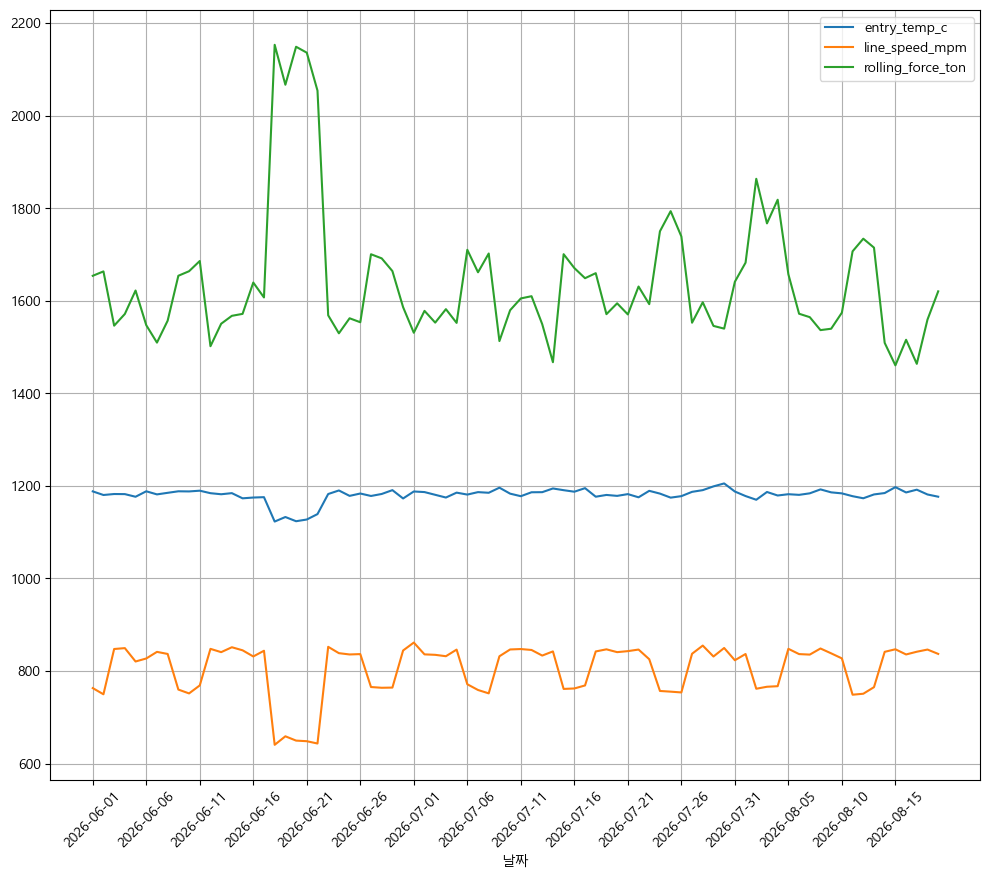

In [9]:
# 03. 운전조건 변화
col_oper = ["steel_grade", "entry_temp_c", "line_speed_mpm", "rolling_force_ton"]

print("\n=== steel grade unique 값 ===\n")
print(df["steel_grade"].unique())

ax = df.plot(x="date", y=col_oper, figsize=(12, 10))
interval = 5
ax.set_xticks(range(0, len(df), interval))
ax.set_xticklabels(df["date"].iloc[::interval])
plt.xlabel("날짜")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

---
> steel_grade 

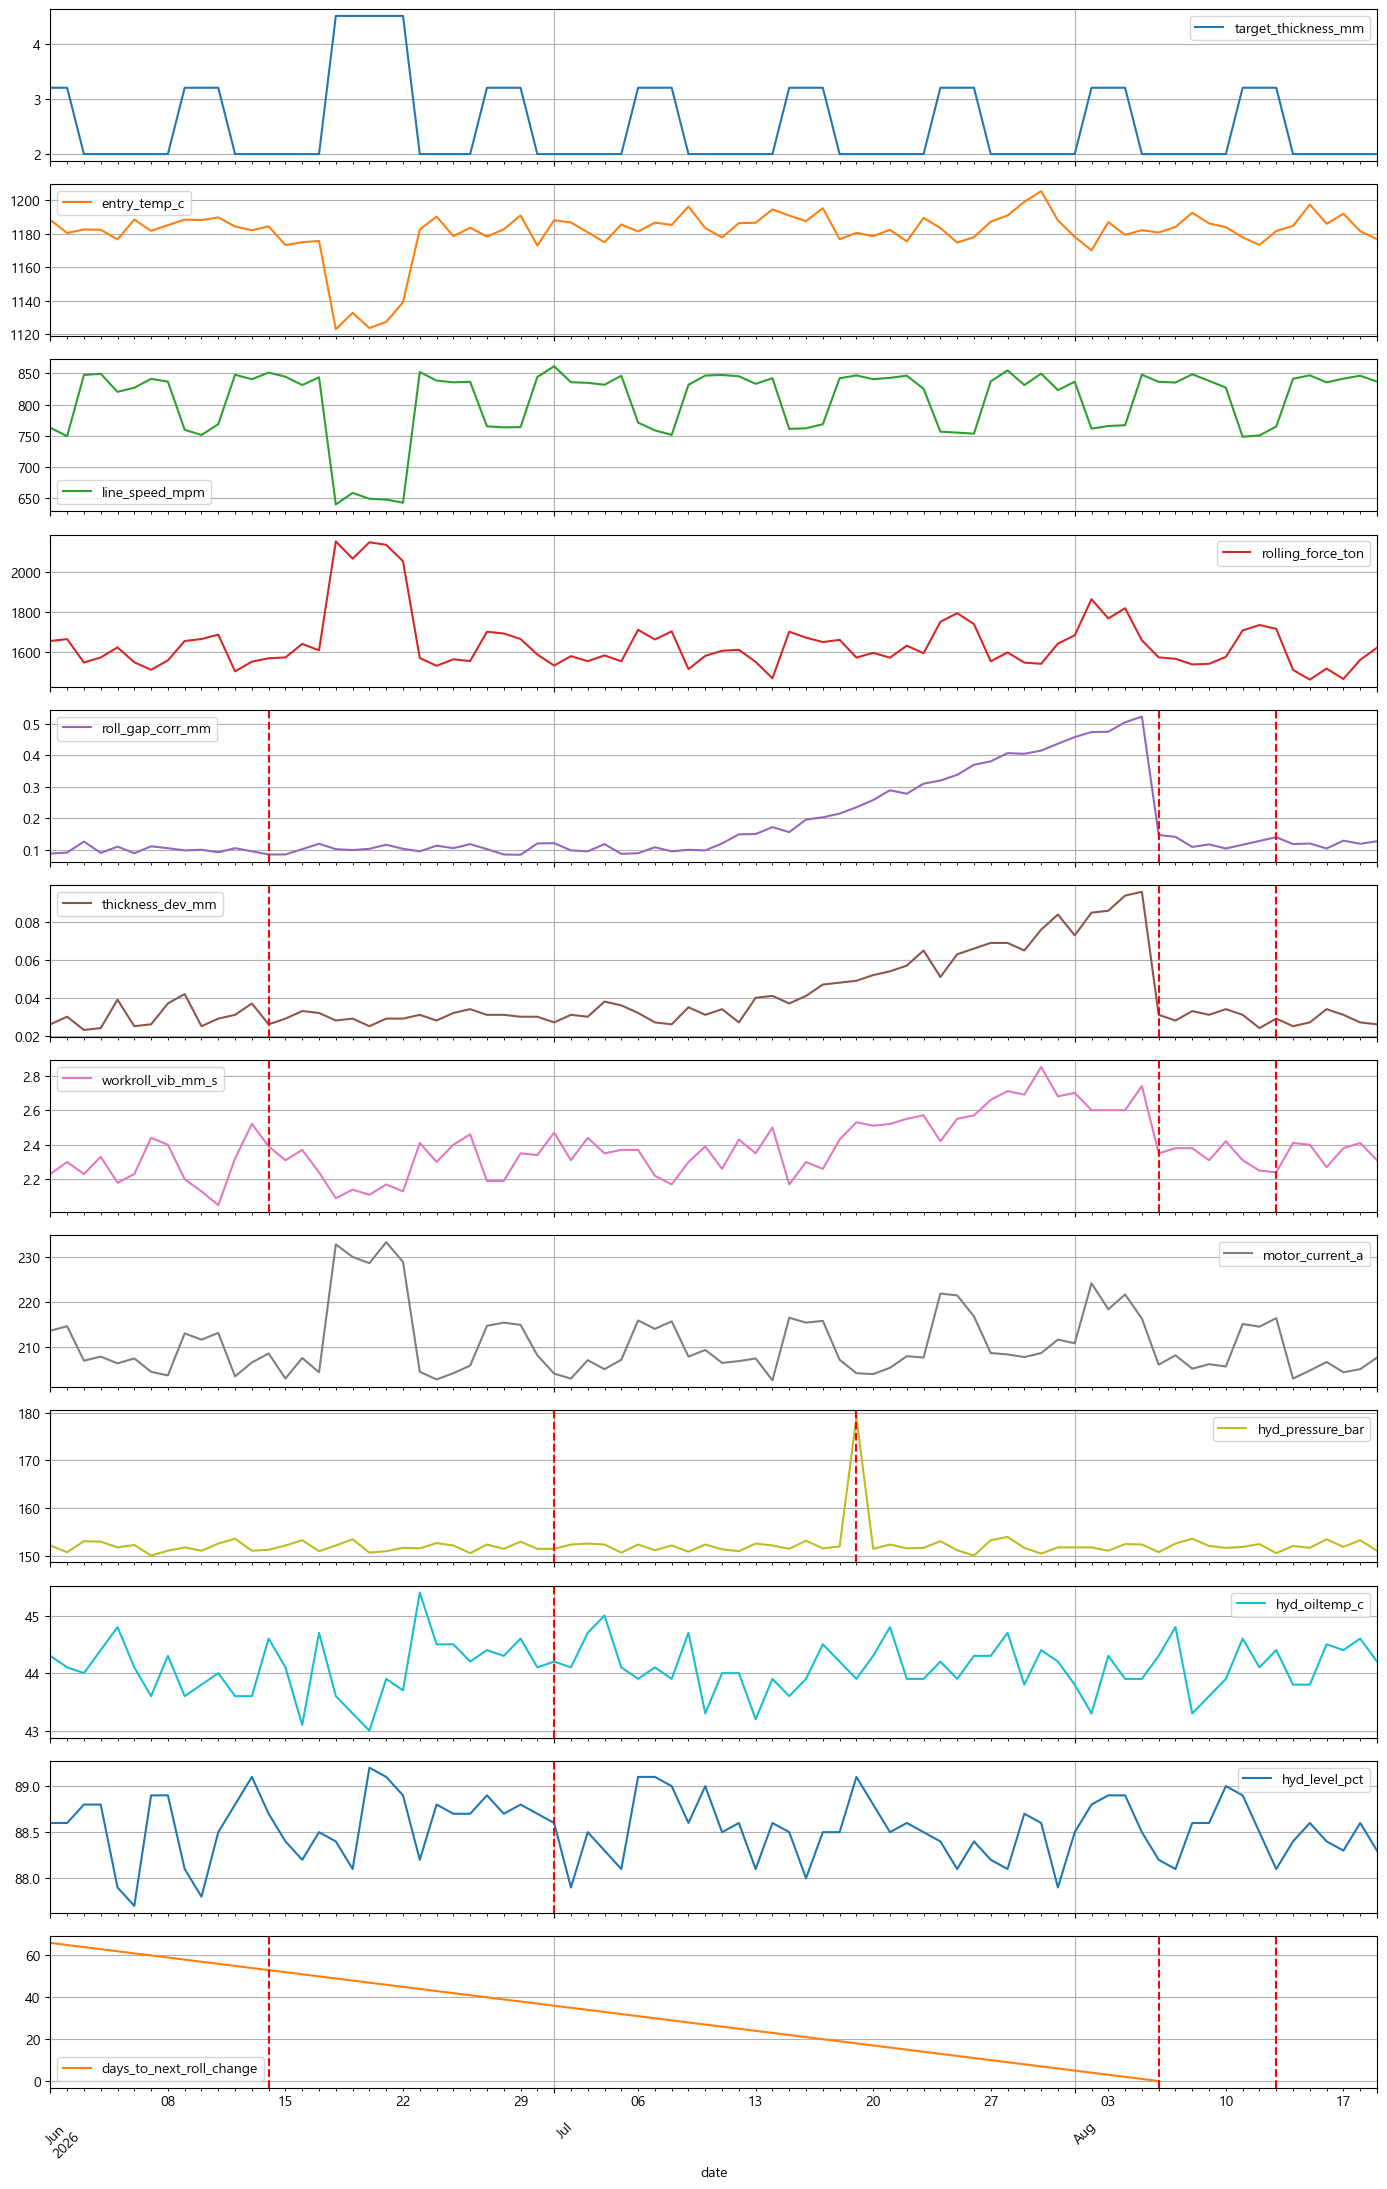

In [10]:
# 04. 센서 이상


df["date"] = pd.to_datetime(df["date"])
hist["event_date"] = pd.to_datetime(hist["event_date"])

numeric_cols = [
    "target_thickness_mm",
    "entry_temp_c",
    "line_speed_mpm",
    "rolling_force_ton",
    "roll_gap_corr_mm",
    "thickness_dev_mm",
    "workroll_vib_mm_s",
    "motor_current_a",
    "hyd_pressure_bar",
    "hyd_oiltemp_c",
    "hyd_level_pct",
    "days_to_next_roll_change",
]

# 정비이력은 운전데이터에 합치지 않고, 관련 있는 그래프에 선을 긋는 데만 사용한다.
maintenance_cols = {
    "작업롤": [
        "roll_gap_corr_mm",
        "thickness_dev_mm",
        "workroll_vib_mm_s",
        "days_to_next_roll_change",
    ],
    "유압 유닛": [
        "hyd_pressure_bar",
        "hyd_oiltemp_c",
        "hyd_level_pct",
    ],
    "유압 압력 센서": [
        "hyd_pressure_bar",
    ],
}

axes = df.plot(
    x="date",
    y=numeric_cols,
    subplots=True,
    figsize=(14, 22),
    sharex=True,
)

axis_by_col = dict(zip(numeric_cols, axes))

for col in numeric_cols:
    axis_by_col[col].grid(True)

for _, row in hist.iterrows():
    related_cols = maintenance_cols.get(row["equipment"], [])

    for col in related_cols:
        axis_by_col[col].axvline(
            x=row["event_date"],
            color="red",
            linestyle="--",
            linewidth=1.5,
        )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **가장 가능성이 높은 원인**
> days_to_next_roll_change 날짜가 가까워지고, 8월 6일에 두께 편차 증가 및 롤 표면 마모 확인 후 교체가 이루어졌기 때문에,
> 작업롤 마모가 가장 큰 원인인 것 같다.

---
### **STEP 3. P-F 간격과 보전 전략**

① P 후보
> 40일쯤____________________________

② F 시점
> 65일____________________________

③ P-F 간격
> 25일____________________________

④ 추천 전략
> PdM 예지보전____________________________

판단
> P-F 간격이 약 25일이고, 현장 리드타임은 10일이라서 확인하고 일정 조율하고 롤 교체까지 할 시간이 있는 것 같다. 그래서 단순히 고장 후 수리보다는 미리 보는 예지보전이 맞는 것 같다.

---
### **STEP 4. 라벨 사건과 라벨 누수**

정비 이력 중 작업롤 마모 사건으로 사용할 기록은?
> M04____________________________

가장 적절한 라벨 창
> B. P ~ F-2일____________________________

이유
> A는 고장 직전이라 너무 늦고, C는 너무 길어서 아직 이상이 아닌 구간도 섞일 수 있다. B가 이상이 시작된 뒤부터 고장 직전 구간 전까지라 제일 맞는 것 같다.

라벨 누수 후보
> days_to_next_roll_change, post_maintenance_result____________________

이유
> days_to_next_roll_change는 다음 롤 교체까지 남은 날짜라서 정비 시점을 거의 알려주는 값이다.
> post_maintenance_result는 정비 후 결과라서 실제 경보 시점에는 알 수 없는 값이다.

---
### **최종 의견**

> 이 라인에서는 작업롤 마모의 가능성이 가장 높다.
> roll_gap_corr_mm, thickness_dev_mm, workroll_vib_mm_s가 같이 증가했고, 67일에 작업롤 마모 확인 후 교체 이력도 있기 때문이다.
> 유압 압력은 49일에 한 번 튄 값이라 지속적인 문제로 보기는 어렵고, 운전조건 변화도 두께 편차 증가와 같이 누적되는 모습은 아닌 것 같다.
> P 후보는 40일쯤, F는 65일로 보면 P-F 간격은 약 25일이라 현장 리드타임 10일 안에 대응 가능하다.
> 따라서 기존 0.09 mm 기준선은 최종 품질 이상 확인용으로 보고, 그보다 앞선 roll_gap_corr_mm이나 workroll_vib_mm_s 추세를 이용해서 예지보전하는 것이 맞는 것 같다.

라벨 정리
> 라벨 사건은 M04이고, 라벨 1 구간은 P부터 F-2일까지로 잡는 게 적절하다.
> F 직전 구간은 이미 고장이 많이 진행된 구간이라 학습에서 제외하는 게 좋다.
> 누수 컬럼은 days_to_next_roll_change와 post_maintenance_result이다.
> 현재 데이터는 기간이 80일이고 작업롤 마모 사건도 1건이라 사례가 적다. 롤 사용 시간, 압연 톤수, 실제 롤 마모량, 더 긴 기간의 정비 이력을 추가로 보면 좋을 것 같다.